In [2]:
!pip install tensorflow

In [3]:
!pip install matplotlib

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
rng = np.random 

In [5]:
#Parameters 

learning_rate = 0.01
training_steps = 1000
display_step = 50

In [6]:
#Training Data 

X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])

Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])

n_samples = X.shape[0]

In [7]:
print(X, '\n', X.shape)

[ 3.3    4.4    5.5    6.71   6.93   4.168  9.779  6.182  7.59   2.167
  7.042 10.791  5.313  7.997  5.654  9.27   3.1  ] 
 (17,)


In [8]:
print(Y, '\n', Y.shape)

[1.7   2.76  2.09  3.19  1.694 1.573 3.366 2.596 2.53  1.221 2.827 3.465
 1.65  2.904 2.42  2.94  1.3  ] 
 (17,)


In [9]:
#Weight and bias, initialised randomly

W = tf.Variable(rng.randn(), name="weight")
b = tf.Variable(rng.randn(), name="bias")

In [10]:
print(W.numpy(), '\n', b.numpy())

0.019446973 
 0.4755513


In [11]:
#Linear regression (Wx+b)

def linear_regression(x):
    return W * x+b 

In [12]:
#Mean square error

def mean_square(y_pred, y_true):
    return tf.reduce_sum(tf.pow(y_pred-y_true, 2)) / (2 * n_samples)

In [13]:
#Stochastic gradient Optimizer

optimizer = tf.optimizers.SGD(learning_rate)

In [14]:
tf.optimizers.SGD?

Init signature:
tf.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.0,
    nesterov=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='SGD',
    **kwargs,
)
Docstring:     
Gradient descent (with momentum) optimizer.

Update rule for parameter `w` with gradient `g` when `momentum` is 0:

```python
w = w - learning_rate * g
```

Update rule when `momentum` is larger than 0:

```python
velocity = momentum * velocity - learning_rate * g
w = w + velocity
```

When `nesterov=True`, this rule becomes:

```python
velocity = momentum * velocity - learning_rate * g
w = w + momentum * velocity - learning_rate * g
```

Args:
    learning_rate: A float, a
        `keras.optimizers.schedules.LearningRateSchedule` instance, or
        a callable that takes no arguments and returns the actual value to


In [20]:
#Optimisation process

def run_optimization():

    #Wrap computation inside a GradientTape for autimatic differentiation
    with tf.GradientTape() as g:
        pred = linear_regression(X)
        loss = mean_square (pred, Y)

    #Compute gradients
    gradients = g.gradient(loss, [W, b])

    #Update W and b following gradients
    optimizer.apply_gradients (zip(gradients, [W, b]))

In [21]:
#Run training for the given number of steps 

for step in range(1, training_steps + 1):

    #Run the optimization to update W and b values
    run_optimization()

    if step% display_step == 0:
        pred = linear_regression(X)
        loss = mean_square (pred, Y)

        print("step: %i, loss: %f, W: %f, b %f" % (step, loss, W.numpy(), b.numpy()))

step: 50, loss: 0.081376, W: 0.289444, b 0.530751
step: 100, loss: 0.080868, W: 0.287216, b 0.546545
step: 150, loss: 0.080417, W: 0.285120, b 0.561408
step: 200, loss: 0.080018, W: 0.283147, b 0.575396
step: 250, loss: 0.079665, W: 0.281290, b 0.588559
step: 300, loss: 0.079352, W: 0.279543, b 0.600947
step: 350, loss: 0.079075, W: 0.277898, b 0.612605
step: 400, loss: 0.078829, W: 0.276351, b 0.623575
step: 450, loss: 0.078612, W: 0.274895, b 0.633900
step: 500, loss: 0.078420, W: 0.273524, b 0.643616
step: 550, loss: 0.078249, W: 0.272234, b 0.652760
step: 600, loss: 0.078098, W: 0.271021, b 0.661365
step: 650, loss: 0.077964, W: 0.269878, b 0.669463
step: 700, loss: 0.077846, W: 0.268804, b 0.677084
step: 750, loss: 0.077741, W: 0.267792, b 0.684255
step: 800, loss: 0.077648, W: 0.266840, b 0.691005
step: 850, loss: 0.077566, W: 0.265944, b 0.697356
step: 900, loss: 0.077493, W: 0.265101, b 0.703333
step: 950, loss: 0.077428, W: 0.264307, b 0.708958
step: 1000, loss: 0.077371, W: 0

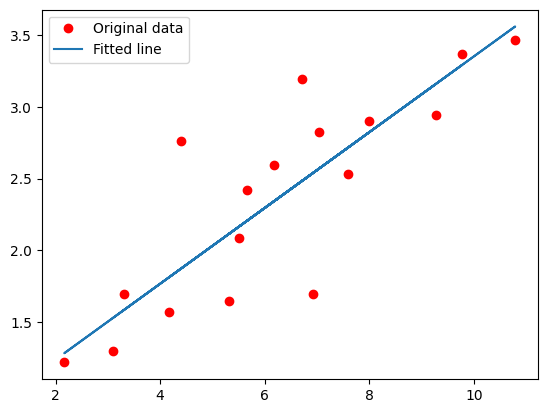

In [22]:
#Plot the Graph

plt.plot(X, Y, 'ro', label='Original data')
plt.plot(X, np.array(W * X+b), label= 'Fitted line')
plt.legend()
plt.show()

C:\TEMP\ipykernel_14288\186010239.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(X, Y, 'ro', color='darkblue', label='Original data')


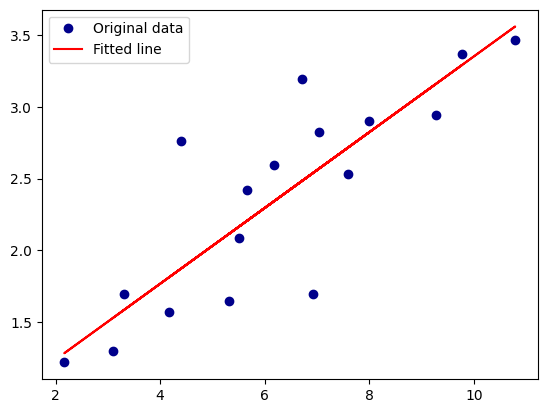

In [30]:
plt.plot(X, Y, 'ro', color='darkblue', label='Original data')
plt.plot(X, np.array(W * X+b), color='red', label= 'Fitted line')
plt.legend()
plt.show()